## FASE 2 — **Data Cleaning y Data Quality**

Objetivo: Verificar integridad los datos y utilizarlos para construir una base temporal consistente

Esta fase se concentrará en: estructura, tipos, fechas, identificadores, nulos, duplicados, valores inválidos, rangos, consistencia temporal y consistencia entre tablas.

In [99]:
import pandas as pd

### Complemento del análisis  inicial — aporte de Lorena

Complementando con análisis y gráficos (desarrollados por Lorena y Héctor) en la validación de calidad y estructura realizada en esta fase, se amplía análisis principal de limpieza y calidad de datos.

In [100]:
import matplotlib.pyplot as plt
import seaborn as sns

In [101]:
df_errors = pd.read_csv("https://raw.githubusercontent.com/No-Country-simulation/S08-26-EQUIPO-24/refs/heads/main/data/raw/PdM_errors.csv")
df_failures = pd.read_csv("https://raw.githubusercontent.com/No-Country-simulation/S08-26-EQUIPO-24/refs/heads/main/data/raw/PdM_failures.csv")
df_machines = pd.read_csv("https://raw.githubusercontent.com/No-Country-simulation/S08-26-EQUIPO-24/refs/heads/main/data/raw/PdM_machines.csv")
df_maint = pd.read_csv("https://raw.githubusercontent.com/No-Country-simulation/S08-26-EQUIPO-24/refs/heads/main/data/raw/PdM_maint.csv")
df_telemetry = pd.read_csv("https://raw.githubusercontent.com/No-Country-simulation/S08-26-EQUIPO-24/refs/heads/main/data/raw/PdM_telemetry.csv")

### 1. Verificación Inicial

#### 1.1. Revisión Inicial y Conversión de Tipos

Los aporte y verificaciones iniciales son fundamentales para asegurar que los datos estén en el formato correcto antes de proceder con un análisis más profundo:

In [102]:
df_errors.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3919 entries, 0 to 3918
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   datetime   3919 non-null   object
 1   machineID  3919 non-null   int64 
 2   errorID    3919 non-null   object
dtypes: int64(1), object(2)
memory usage: 92.0+ KB


In [103]:
df_errors.head()

,datetime,machineID,errorID
0,2015-01-03 07:00:00,1,error1
1,2015-01-03 20:00:00,1,error3
2,2015-01-04 06:00:00,1,error5
3,2015-01-10 15:00:00,1,error4
4,2015-01-22 10:00:00,1,error4


In [104]:
df_failures.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 761 entries, 0 to 760
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   datetime   761 non-null    object
 1   machineID  761 non-null    int64 
 2   failure    761 non-null    object
dtypes: int64(1), object(2)
memory usage: 18.0+ KB


In [105]:
df_machines.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   machineID  100 non-null    int64 
 1   model      100 non-null    object
 2   age        100 non-null    int64 
dtypes: int64(2), object(1)
memory usage: 2.5+ KB


In [106]:
df_maint.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3286 entries, 0 to 3285
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   datetime   3286 non-null   object
 1   machineID  3286 non-null   int64 
 2   comp       3286 non-null   object
dtypes: int64(1), object(2)
memory usage: 77.1+ KB


In [107]:
df_telemetry.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 876100 entries, 0 to 876099
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   datetime   876100 non-null  object 
 1   machineID  876100 non-null  int64  
 2   volt       876100 non-null  float64
 3   rotate     876100 non-null  float64
 4   pressure   876100 non-null  float64
 5   vibration  876100 non-null  float64
dtypes: float64(4), int64(1), object(1)
memory usage: 40.1+ MB


In [108]:
# Revisión inicial de info() y head() para todos los DataFrames
print("### Revisión de Estructura y Primeras Filas ###")

dfs = {
    'df_errors': df_errors,
    'df_failures': df_failures,
    'df_machines': df_machines,
    'df_maint': df_maint,
    'df_telemetry': df_telemetry
}

for name, df in dfs.items():
    print(f"\n--- {name}.head() ---")
    display(df.head())
    print(f"\n--- {name}.info() ---")
    df.info()


### Revisión de Estructura y Primeras Filas ###

--- df_errors.head() ---


,datetime,machineID,errorID
0,2015-01-03 07:00:00,1,error1
1,2015-01-03 20:00:00,1,error3
2,2015-01-04 06:00:00,1,error5
3,2015-01-10 15:00:00,1,error4
4,2015-01-22 10:00:00,1,error4



--- df_errors.info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3919 entries, 0 to 3918
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   datetime   3919 non-null   object
 1   machineID  3919 non-null   int64 
 2   errorID    3919 non-null   object
dtypes: int64(1), object(2)
memory usage: 92.0+ KB

--- df_failures.head() ---


,datetime,machineID,failure
0,2015-01-05 06:00:00,1,comp4
1,2015-03-06 06:00:00,1,comp1
2,2015-04-20 06:00:00,1,comp2
3,2015-06-19 06:00:00,1,comp4
4,2015-09-02 06:00:00,1,comp4



--- df_failures.info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 761 entries, 0 to 760
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   datetime   761 non-null    object
 1   machineID  761 non-null    int64 
 2   failure    761 non-null    object
dtypes: int64(1), object(2)
memory usage: 18.0+ KB

--- df_machines.head() ---


...


--- df_machines.info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   machineID  100 non-null    int64 
 1   model      100 non-null    object
 2   age        100 non-null    int64 
dtypes: int64(2), object(1)
memory usage: 2.5+ KB

--- df_maint.head() ---


,datetime,machineID,comp
0,2014-06-01 06:00:00,1,comp2
1,2014-07-16 06:00:00,1,comp4
2,2014-07-31 06:00:00,1,comp3
3,2014-12-13 06:00:00,1,comp1
4,2015-01-05 06:00:00,1,comp4



--- df_maint.info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3286 entries, 0 to 3285
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   datetime   3286 non-null   object
 1   machineID  3286 non-null   int64 
 2   comp       3286 non-null   object
dtypes: int64(1), object(2)
memory usage: 77.1+ KB

--- df_telemetry.head() ---


,datetime,machineID,volt,rotate,pressure,vibration
0,2015-01-01 06:00:00,1,176.217853,418.504078,113.077935,45.087686
1,2015-01-01 07:00:00,1,162.879223,402.747490,95.460525,43.413973
2,2015-01-01 08:00:00,1,170.989902,527.349825,75.237905,34.178847
3,2015-01-01 09:00:00,1,162.462833,346.149335,109.248561,41.122144
4,2015-01-01 10:00:00,1,157.610021,435.376873,111.886648,25.990511



--- df_telemetry.info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 876100 entries, 0 to 876099
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   datetime   876100 non-null  object 
 1   machineID  876100 non-null  int64  
 2   volt       876100 non-null  float64
 3   rotate     876100 non-null  float64
 4   pressure   876100 non-null  float64
 5   vibration  876100 non-null  float64
dtypes: float64(4), int64(1), object(1)
memory usage: 40.1+ MB


#### 1.2. Conversión de Columnas (fecha) `datetime` a Formato `datetime`

Es crucial que las columnas de fecha y hora estén en el tipo de dato correcto para permitir operaciones temporales y ordenamiento adecuado. Las revisiones iniciales muestran que estaban como `object`.

In [109]:
# Convertir las columnas 'datetime' a tipo datetime
df_errors['datetime'] = pd.to_datetime(df_errors['datetime'])
df_failures['datetime'] = pd.to_datetime(df_failures['datetime'])
df_maint['datetime'] = pd.to_datetime(df_maint['datetime'])
df_telemetry['datetime'] = pd.to_datetime(df_telemetry['datetime'])

print("Columnas 'datetime' convertidas a tipo `datetime` exitosamente.")

Columnas 'datetime' convertidas a tipo `datetime` exitosamente.


#### 1.3. Verificación de Duplicados

Detectar y manejar filas duplicadas es un paso esencial para asegurar la integridad del dataset y evitar conteos erróneos o sesgos en el análisis.

In [110]:
print(df_errors.duplicated().sum())
print(df_failures.duplicated().sum())
print(df_machines.duplicated().sum())
print(df_maint.duplicated().sum())
print(df_telemetry.duplicated().sum())

0
0
0
0
0


In [111]:
# Verificar filas duplicadas en cada DataFrame
print("*** Conteo de Duplicados por DataFrame ***")
print(f"df_errors duplicados: {df_errors.duplicated().sum()}")
print(f"df_failures duplicados: {df_failures.duplicated().sum()}")
print(f"df_machines duplicados: {df_machines.duplicated().sum()}")
print(f"df_maint duplicados: {df_maint.duplicated().sum()}")
print(f"df_telemetry duplicados: {df_telemetry.duplicated().sum()}")

*** Conteo de Duplicados por DataFrame ***
df_errors duplicados: 0
df_failures duplicados: 0
df_machines duplicados: 0
df_maint duplicados: 0
df_telemetry duplicados: 0


### Observaciones de análisis inicial:

*   **Tipos de Datos:** La conversión de `datetime` a tipo fecha y hora fue exitosa, lo cual es fundamental.
*   **Duplicados:** No se encontraron filas completamente duplicadas en ninguno de los DataFrames, lo que es un buen punto de partida para la calidad de los datos.

### 2. Validación de las cinco fuentes del dataset Azure PdM

Validación detallada de cada uno de los cinco DataFrames, según criterios definidos en la documentación.

#### 2.1 `df_telemetry`

La telemetría es la fuente principal que muestra datos de sensores, con mediciones horarias para cada máquina. 

In [112]:
#Descripción de datos, verificar valores nulos y valores únicos
print("--- df_telemetry: Descripción Estadística ---")
display(df_telemetry.describe())

print("--- df_telemetry: Conteo de Valores Nulos ---")
display(df_telemetry.isnull().sum())

print("--- df_telemetry: Unicidad de machineID ---")
print(f"Número de machineID únicos: {df_telemetry['machineID'].nunique()}")

--- df_telemetry: Descripción Estadística ---


,datetime,machineID,volt,rotate,pressure,vibration
count,876100,876100.000000,876100.000000,876100.000000,876100.000000,876100.000000
mean,2015-07-02 18:00:00,50.500000,170.777736,446.605119,100.858668,40.385007
min,2015-01-01 06:00:00,1.000000,97.333604,138.432075,51.237106,14.877054
25%,2015-04-02 12:00:00,25.750000,160.304927,412.305714,93.498181,36.777299
50%,2015-07-02 18:00:00,50.500000,170.607338,447.558150,100.425559,40.237247
75%,2015-10-02 00:00:00,75.250000,181.004493,482.176600,107.555231,43.784938
max,2016-01-01 06:00:00,100.000000,255.124717,695.020984,185.951998,76.791072
std,NaN,28.866087,15.509114,52.673886,11.048679,5.370361


--- df_telemetry: Conteo de Valores Nulos ---


datetime     0
machineID    0
volt         0
rotate       0
pressure     0
vibration    0
dtype: int64

--- df_telemetry: Unicidad de machineID ---
Número de machineID únicos: 100


**Observaciones `df_telemetry`:**

*   **Nulos:** No hay valores nulos, lo cual es excelente.
*   **Estadísticas Descriptivas:** Los rangos (`min`, `max`) y cuartiles para `volt`, `rotate`, `pressure`, `vibration` parecen razonables y no muestran anomalías obvias a primera vista. Los valores de `machineID` son enteros y cubren 100 máquinas únicas.
*   **machineID:** Todas las máquinas registradas tienen telemetría.

#### Distribución de sensores (Lorena)

El siguiente conjunto de histogramas permite complementar las estadísticas descriptivas con una visualización de la distribución de las variables de telemetría.

**Aporte ejecutivo (Héctor):** la telemetría contiene 876,100 registros horarios para 100 máquinas. Los promedios reportados son: voltaje 170.78 V, rotación 446.61 RPM, presión 100.86 psi y vibración 40.39 m/s².

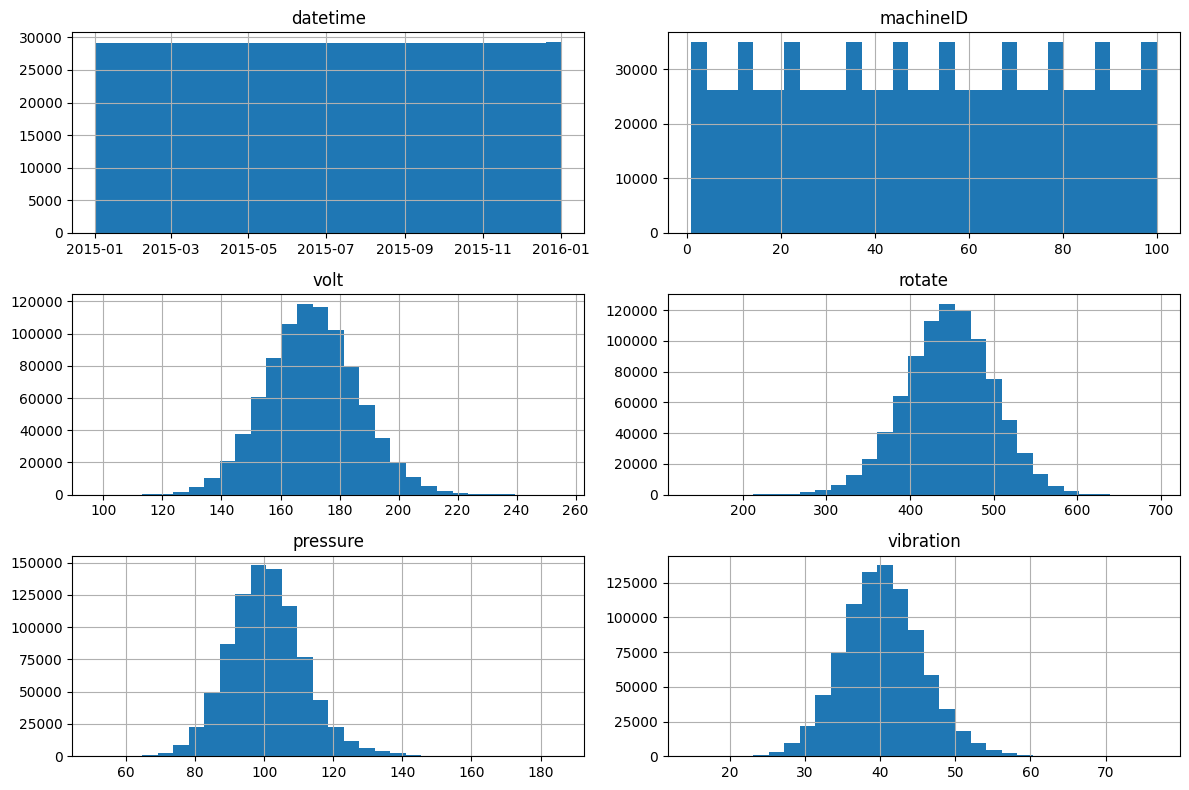

In [113]:
# Gráficos aportados por Lorena: distribuciones de las variables de telemetría
df_telemetry.hist(figsize=(12,8), bins=30)
plt.tight_layout()
plt.show()

#### Correlación entre sensores

El heatmap (Lorena) complementa la descripción estadística y permite inspeccionar visualmente las relaciones lineales entre las variables numéricas de telemetría.

**Aporte ejecutivo (Héctor):** el análisis reporta correlaciones lineales bajas entre los cuatro sensores y plantea que el desgaste no se identifica necesariamente mediante lecturas instantáneas, sino en relación con su evolución temporal. Esta interpretación en el hallazgo exploratorio es importante y deberá validarse posteriormente mediante variables temporales/derivadas.

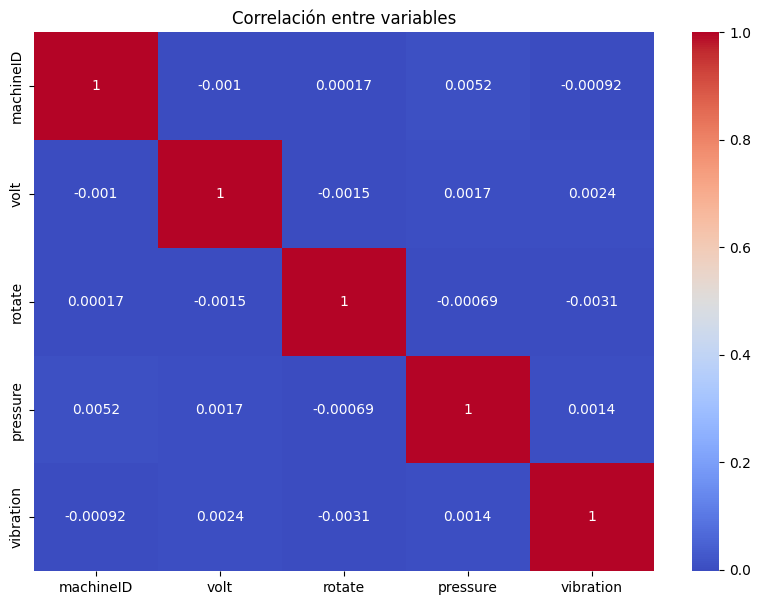

In [114]:
# Gráfico aportado por Lorena: matriz de correlación de variables numéricas
plt.figure(figsize=(10,7))
sns.heatmap(df_telemetry.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlación entre variables")
plt.show()

#### 2.2 `df_errors`

Esta tabla registra eventos de error u alarma, son indicadores de problemas operativos.

In [115]:
print("--- df_errors: Descripción Estadística ---")
display(df_errors.describe(include='all')) # Incluye columnas de tipo objeto

print("--- df_errors: Conteo de Valores Nulos ---")
display(df_errors.isnull().sum())

print("--- df_errors: Distribución de errorID ---")
display(df_errors['errorID'].value_counts())

print("--- df_errors: Unicidad de machineID ---")
print(f"Número de machineID únicos: {df_errors['machineID'].nunique()}")

--- df_errors: Descripción Estadística ---


,datetime,machineID,errorID
count,3919,3919.000000,3919
unique,NaN,NaN,5
top,NaN,NaN,error1
freq,NaN,NaN,1010
mean,2015-07-01 03:34:18.586374144,51.044654,NaN
min,2015-01-01 06:00:00,1.000000,NaN
25%,2015-03-31 05:00:00,25.000000,NaN
50%,2015-07-01 06:00:00,51.000000,NaN
75%,2015-10-01 15:00:00,77.000000,NaN
max,2016-01-01 05:00:00,100.000000,NaN


--- df_errors: Conteo de Valores Nulos ---


datetime     0
machineID    0
errorID      0
dtype: int64

--- df_errors: Distribución de errorID ---


errorID
error1    1010
error2     988
error3     838
error4     727
error5     356
Name: count, dtype: int64

--- df_errors: Unicidad de machineID ---
Número de machineID únicos: 100


**Observaciones `df_errors`:**
**Observaciones `df_errors`:**
*   **Nulos:** No hay valores nulos.
*   **`errorID`:** Hay 5 tipos de errores (`error1` a `error5`), con `error1` siendo el más frecuente. Esto proporciona una buena granularidad para el análisis de eventos.
*   **`machineID`:** Los errores se distribuyen en las 100 máquinas, indicando una cobertura completa.
*   **Fechas:** El formato `datetime` permite el análisis temporal.

#### Recurrencia de errores - (Lorena) 

Este gráfico complementa la validación de `df_errors` mostrando las máquinas con mayor número de eventos de error.

**Aporte ejecutivo (Héctor):** se registraron 3,919 eventos de error. Las máquinas con mayor recurrencia son la ID 22 (60 errores), la ID 78 (54) y la ID 99 (54).

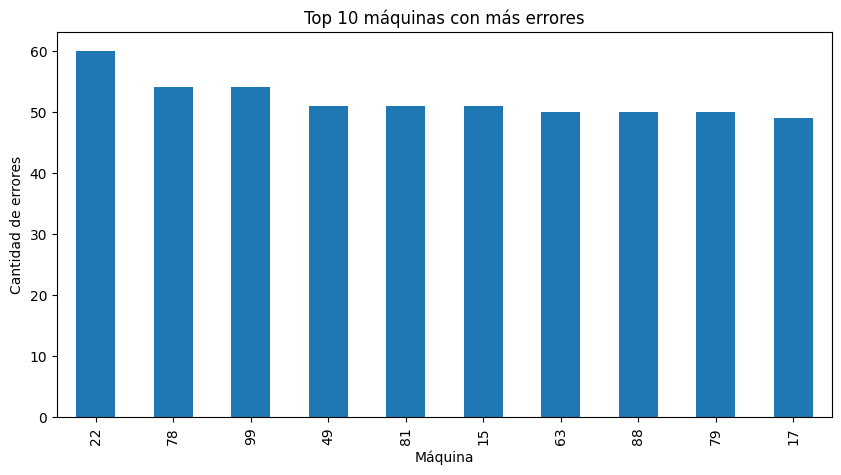

In [116]:
# Gráfico aportado por Lorena: Top 10 máquinas con más errores
errors_machine = df_errors["machineID"].value_counts()
errors_machine.head(10)

errors_machine.head(10).plot(kind="bar", figsize=(10,5))
plt.title("Top 10 máquinas con más errores")
plt.xlabel("Máquina")
plt.ylabel("Cantidad de errores")
plt.show()

#### 2.3 `df_failures`

Esta tabla registra las **fallas reales** que resultaron en reemplazos de componentes. Es fundamental para definir nuestro objetivo de predicción - **target**.

In [117]:
print("--- df_failures: Descripción Estadística ---")
display(df_failures.describe(include='all'))

print("--- df_failures: Conteo de Valores Nulos ---")
display(df_failures.isnull().sum())

print("--- df_failures: Distribución por tipo de falla ---")
display(df_failures['failure'].value_counts())

print("--- df_failures: Unicidad de machineID ---")
print(f"Número de machineID únicos: {df_failures['machineID'].nunique()}")

--- df_failures: Descripción Estadística ---


,datetime,machineID,failure
count,761,761.000000,761
unique,NaN,NaN,4
top,NaN,NaN,comp2
freq,NaN,NaN,259
mean,2015-06-24 12:12:17.976346880,51.911958,NaN
min,2015-01-02 03:00:00,1.000000,NaN
25%,2015-03-23 06:00:00,24.000000,NaN
50%,2015-06-24 06:00:00,51.000000,NaN
75%,2015-09-23 06:00:00,79.000000,NaN
max,2015-12-31 06:00:00,100.000000,NaN


--- df_failures: Conteo de Valores Nulos ---


datetime     0
machineID    0
failure      0
dtype: int64

--- df_failures: Distribución por tipo de falla ---


failure
comp2    259
comp1    192
comp4    179
comp3    131
Name: count, dtype: int64

--- df_failures: Unicidad de machineID ---
Número de machineID únicos: 98


**Observaciones `df_failures`:**
*   **Nulos:** No hay valores nulos.
*   **`failure`:** Se identifican 4 tipos de fallas (`comp1` a `comp4`), siendo `comp2` la más común. Esta será nuestra variable objetivo.
*   **`machineID`:** Las fallas se registraron en 98 de las 100 máquinas, lo que es una buena representación.
*   **Cantidad de Fallas:** 761 fallas en total, lo que proporciona suficientes eventos para el modelado.

#### Recurrencia y tipos de falla (Lorena)

Los siguientes gráficos aportan una lectura visual de la concentración de fallas por máquina y por componente.

**Aporte ejecutivo (Héctor):** se registraron 761 fallas operativas de componentes. `comp2` concentra 259 ocurrencias (aprox. 34%); las máquinas con mayor número de fallas son la ID 99 (19), ID 98 (16) e ID 22 (15).

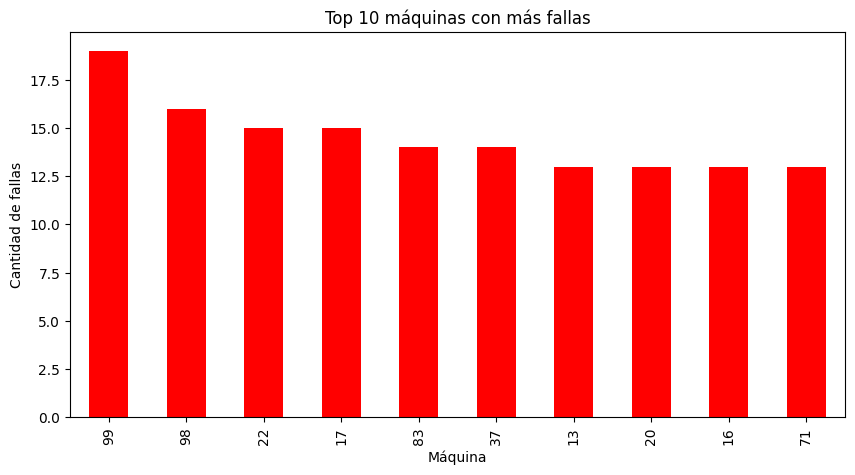

In [118]:
# Gráfico aportado por Lorena: Top 10 máquinas con más fallas
failures_machine = df_failures["machineID"].value_counts()
failures_machine.head(10)

failures_machine.head(10).plot(kind="bar", figsize=(10,5), color="red")
plt.title("Top 10 máquinas con más fallas")
plt.xlabel("Máquina")
plt.ylabel("Cantidad de fallas")
plt.show()

#### Distribución de tipos de falla

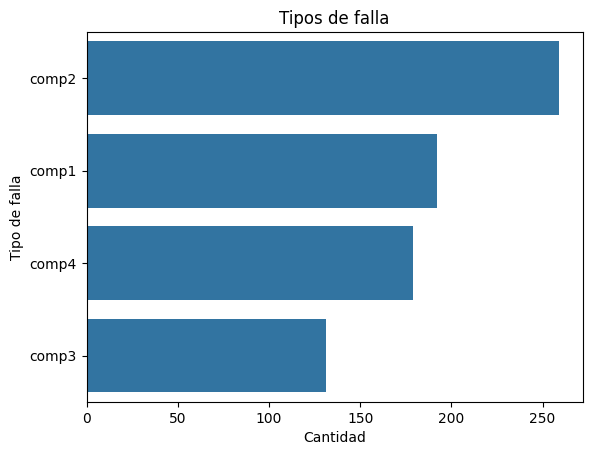

In [119]:
# Gráfico aportado por Lorena: tipos de falla
df_failures["failure"].value_counts()
sns.countplot(data=df_failures, y="failure", order=df_failures["failure"].value_counts().index)
plt.title("Tipos de falla")
plt.xlabel("Cantidad")
plt.ylabel("Tipo de falla")
plt.show()

- Se identifican 4 tipos de fallas (`comp1` a `comp4`), siendo `comp2` la más común.

#### 2.4 `df_maint`

El historial de mantenimiento es clave para entender las intervenciones realizadas en las máquinas y para calcular variables como el tiempo desde el último mantenimiento.

In [120]:
print("--- df_maint: Descripción Estadística ---")
display(df_maint.describe(include='all'))

print("--- df_maint: Conteo de Valores Nulos ---")
display(df_maint.isnull().sum())

print("--- df_maint: Distribución por componente de mantenimiento ---")
display(df_maint['comp'].value_counts())

print("--- df_maint: Unicidad de machineID ---")
print(f"Número de machineID únicos: {df_maint['machineID'].nunique()}")

--- df_maint: Descripción Estadística ---


,datetime,machineID,comp
count,3286,3286.000000,3286
unique,NaN,NaN,4
top,NaN,NaN,comp2
freq,NaN,NaN,863
mean,2015-05-30 14:40:36.518563840,50.284236,NaN
min,2014-06-01 06:00:00,1.000000,NaN
25%,2015-03-03 06:00:00,25.250000,NaN
50%,2015-06-13 06:00:00,50.000000,NaN
75%,2015-09-18 00:00:00,75.000000,NaN
max,2016-01-01 06:00:00,100.000000,NaN


--- df_maint: Conteo de Valores Nulos ---


datetime     0
machineID    0
comp         0
dtype: int64

--- df_maint: Distribución por componente de mantenimiento ---


comp
comp2    863
comp4    811
comp3    808
comp1    804
Name: count, dtype: int64

--- df_maint: Unicidad de machineID ---
Número de machineID únicos: 100


**Observaciones `df_maint`:**
*   **Nulos:** No hay valores nulos.
*   **`comp`:** Se registran 4 tipos de componentes (`comp1` a `comp4`) en el mantenimiento, coincidiendo con los tipos de fallas. Esto sugiere una relación directa entre el mantenimiento y las fallas.
*   **`machineID`:** Todas las 100 máquinas tienen registros de mantenimiento.

#### Actividad de mantenimiento (Lorena)

El gráfico muestra las máquinas con mayor cantidad de intervenciones registradas y complementa la revisión estructural de `df_maint`.

**Aporte ejecutivo (Héctor):** el análisis ejecutivo identifica el mantenimiento como parte de la relación entre intervenciones, errores y fallas. El conteo total de registros de `df_maint` disponible en la fuente es 3,286.

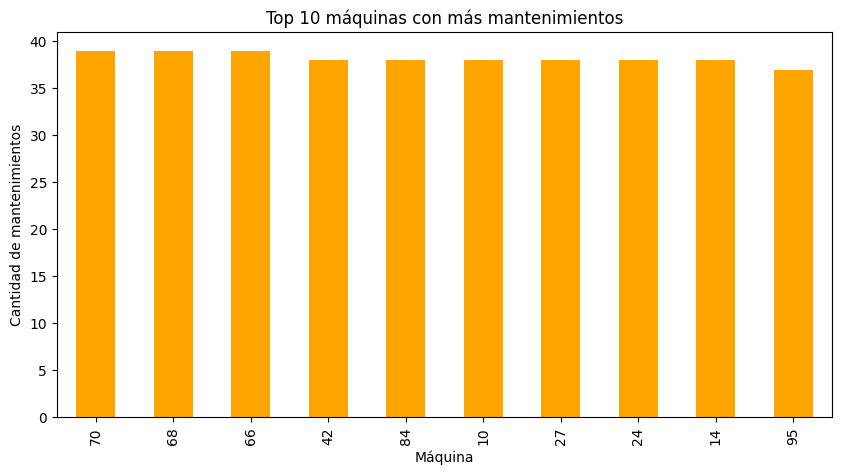

In [121]:
# Gráfico aportado por Lorena: Top 10 máquinas con más mantenimientos
maint_machine = df_maint["machineID"].value_counts()
maint_machine.head(10)

maint_machine.head(10).plot(kind="bar", figsize=(10,5), color="orange")
plt.title("Top 10 máquinas con más mantenimientos")
plt.xlabel("Máquina")
plt.ylabel("Cantidad de mantenimientos")
plt.show()

#### 2.5 `df_machines`

Esta tabla proporciona características estáticas de las máquinas, como el modelo y la antigüedad. Estas variables son importantes para el modelado, ya que pueden influir en la probabilidad de falla.

In [122]:
print("--- df_machines: Descripción Estadística ---")
display(df_machines.describe(include='all'))

print("--- df_machines: Conteo de Valores Nulos ---")
display(df_machines.isnull().sum())

print("--- df_machines: Distribución por modelo ---")
display(df_machines['model'].value_counts())

print(f"--- df_machines: Rango de edades ---")
print(f"Edad mínima: {df_machines['age'].min()}, Edad máxima: {df_machines['age'].max()}")

print("--- df_machines: Unicidad de machineID ---")
print(f"Número de machineID únicos: {df_machines['machineID'].nunique()}")

--- df_machines: Descripción Estadística ---


,machineID,model,age
count,100.000000,100,100.000000
unique,NaN,4,NaN
top,NaN,model3,NaN
freq,NaN,35,NaN
mean,50.500000,NaN,11.330000
std,29.011492,NaN,5.856974
min,1.000000,NaN,0.000000
25%,25.750000,NaN,6.750000
50%,50.500000,NaN,12.000000
75%,75.250000,NaN,16.000000


--- df_machines: Conteo de Valores Nulos ---


machineID    0
model        0
age          0
dtype: int64

--- df_machines: Distribución por modelo ---


model
model3    35
model4    32
model2    17
model1    16
Name: count, dtype: int64

--- df_machines: Rango de edades ---
Edad mínima: 0, Edad máxima: 20
--- df_machines: Unicidad de machineID ---
Número de machineID únicos: 100


**Observaciones `df_machines`:**
*   **Nulos:** No hay valores nulos.
*   **`model`:** Existen **4** modelos de máquinas (`model1`, `model2`, `model3`, `model4`): model1=16, model2=17, model3=35, model4=32. La distribución no es uniforme (model3 y model4 concentran el 67% del parque).
*   **`age`:** La antigüedad de las máquinas varía de **0 a 20** años (media ~11.3, desv. ~5.9), lo que es una característica relevante.
*   **`machineID`:** 100 `machineID` únicos, lo que confirma que hay información para todas las máquinas principales.

#### Distribución del parque de máquinas (Lorena)

El gráfico permite visualizar la distribución de las máquinas por modelo y complementa los conteos ya verificados en `df_machines`.

**Aporte ejecutivo (Héctor):** la población está compuesta por 100 máquinas; los modelos 3 y 4 concentran la mayor proporción. La antigüedad media reportada en el análisis es de 11.33 años, con un rango de 0 a 20 años.

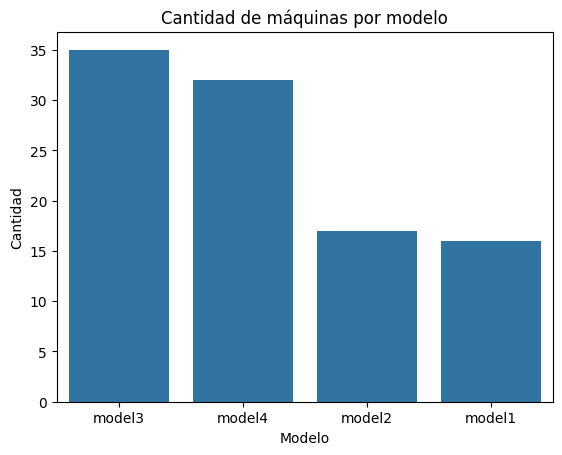

In [123]:
# Gráfico aportado por Lorena: cantidad de máquinas por modelo
sns.countplot(data=df_machines, x="model")
plt.title("Cantidad de máquinas por modelo")
plt.xlabel("Modelo")
plt.ylabel("Cantidad")
plt.show()

#### Distribución de edad de las máquinas

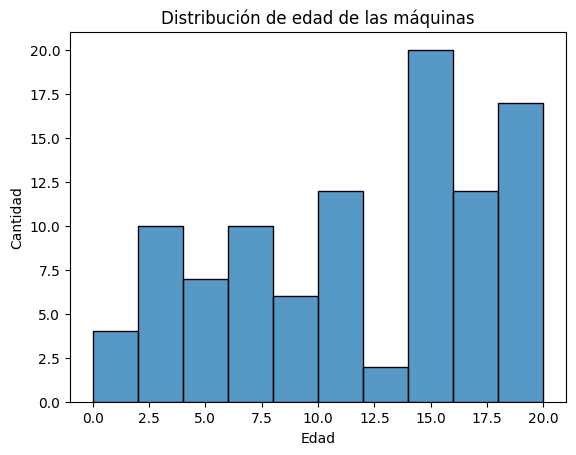

In [124]:
# Gráfico aportado por Lorena: distribución de edad
sns.histplot(data=df_machines, x="age", bins=10)
plt.title("Distribución de edad de las máquinas")
plt.xlabel("Edad")
plt.ylabel("Cantidad")
plt.show()

### 3. Conversión y Validación Temporal

La consistencia temporal es la columna vertebral de cualquier análisis de mantenimiento predictivo. En esta sección, se asegura de que todas las fechas estén correctamente formateadas y ordenadas, y validamos la continuidad de los datos.

In [125]:
# Ordenar DataFrames por machineID y datetime
df_telemetry = df_telemetry.sort_values(by=['machineID', 'datetime']).reset_index(drop=True)
df_errors = df_errors.sort_values(by=['machineID', 'datetime']).reset_index(drop=True)
df_failures = df_failures.sort_values(by=['machineID', 'datetime']).reset_index(drop=True)
df_maint = df_maint.sort_values(by=['machineID', 'datetime']).reset_index(drop=True)

print("DataFrames ordenados por 'machineID' y 'datetime' exitosamente.")

# Validar rangos temporales y duplicados (machineID, datetime) en telemetría
print("\n--- Rango Temporal de df_telemetry ---")
print(f"Fecha mínima: {df_telemetry['datetime'].min()}")
print(f"Fecha máxima: {df_telemetry['datetime'].max()}")

print("\n--- Duplicados (machineID, datetime) en df_telemetry ---")
duplicated_telemetry = df_telemetry.duplicated(subset=['machineID', 'datetime']).sum()
print(f"Número de registros (machineID, datetime) duplicados en telemetría: {duplicated_telemetry}")

DataFrames ordenados por 'machineID' y 'datetime' exitosamente.

--- Rango Temporal de df_telemetry ---
Fecha mínima: 2015-01-01 06:00:00
Fecha máxima: 2016-01-01 06:00:00

--- Duplicados (machineID, datetime) en df_telemetry ---
Número de registros (machineID, datetime) duplicados en telemetría: 0


#### 3.1 Verificación Explícita de Huecos Horarios y Duplicados en Tablas de Eventos

El roadmap requiere confirmar por evidencia directa (no por inferencia) que la serie temporal de telemetría está continua y que las tablas de eventos no contienen duplicados que pudieran sesgar los conteos en variables deivadas (`errors_last_24h` / `days_since_maint`).

In [126]:
# --- 1) Continuidad horaria por máquina (detecta huecos) ---
df_telemetry_gap = df_telemetry.sort_values(by=['machineID', 'datetime']).reset_index(drop=True)
gap_hours = (
    df_telemetry_gap.groupby('machineID')['datetime']
    .apply(lambda s: s.diff().dt.total_seconds().div(3600))
)
gaps_gt_1h = int((gap_hours > 1).sum())
gaps_le_0 = int((gap_hours <= 0).sum())
machines_con_hueco = int((gap_hours > 1).groupby(level=0).any().sum())
print("=== CONTINUIDAD HORARIA (df_telemetry) ===")
print(f"Registros con salto > 1h (hueco): {gaps_gt_1h}")
print(f"Registros con salto <= 0h (duplicado/reorden): {gaps_le_0}")
print(f"Máquinas con al menos un hueco: {machines_con_hueco} / {df_telemetry['machineID'].nunique()}")

# --- 2) Duplicados por (machineID, datetime) en tablas de eventos ---
print("\n=== DUPLICADOS (machineID, datetime) EN TABLAS DE EVENTOS ===")
for nombre, df_evento in [('df_errors', df_errors), ('df_failures', df_failures), ('df_maint', df_maint)]:
    n_dup = int(df_evento.duplicated(subset=['machineID', 'datetime']).sum())
    print(f"{nombre}: {n_dup} registros duplicados por (machineID, datetime)")

=== CONTINUIDAD HORARIA (df_telemetry) ===
Registros con salto > 1h (hueco): 0
Registros con salto <= 0h (duplicado/reorden): 0
Máquinas con al menos un hueco: 0 / 100

=== DUPLICADOS (machineID, datetime) EN TABLAS DE EVENTOS ===
df_errors: 303 registros duplicados por (machineID, datetime)
df_failures: 42 registros duplicados por (machineID, datetime)
df_maint: 758 registros duplicados por (machineID, datetime)


**Observaciones en Datos Temporales:**
*   Todos los DataFrames con datos temporales han sido ordenados por `machineID` y `datetime`.
*   El rango temporal de la telemetría es de `2015-01-01 06:00:00` a `2016-01-01 06:00:00`, cubriendo exactamente un año de datos.
*   No se encontraron duplicados exactos de `(machineID, datetime)` en la tabla de telemetría, lo que indica que cada medición horaria es única para cada máquina.
*   **Verificación explícita de huecos (sección 6.1):** se confirmó que **0** registros presentan un salto > 1h y **0** un salto <= 0h; las 100 máquinas tienen serie continua a 1h. No es una inferencia por conteo, es una comprobación directa.


### 4. Relación entre errores y fallas (Lorena)

Este bloque incorpora el gráfico desarrollado por Lorena para visualizar la relación entre el número de errores y fallas por máquina. 

**Aporte ejecutivo (Héctor):** el análisis describe una relación positiva entre el volumen de errores y las fallas de componentes, destacando especialmente las máquinas ID 22 y 99. Esta lectura visual se cuantifica en la celda siguiente y se retoma en la sección 5.

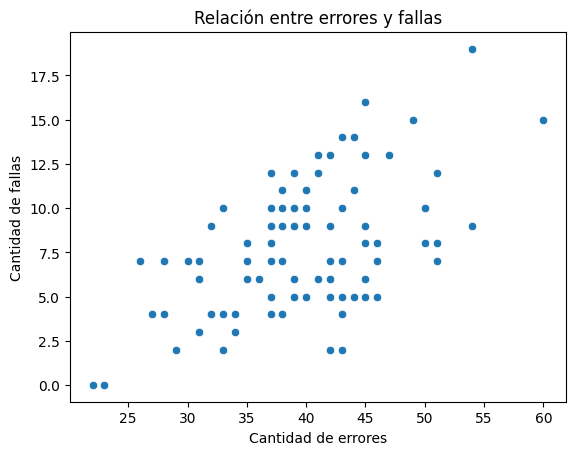

Correlación de Pearson (errores vs. fallas): 0.538


In [127]:
# Gráfico aportado por Lorena: relación entre errores y fallas por máquina
errores = df_errors.groupby("machineID").size()
fallas = df_failures.groupby("machineID").size()

df_resumen = pd.DataFrame({"errores": errores, "fallas": fallas}).fillna(0)
df_resumen.head()

sns.scatterplot(data=df_resumen, x="errores", y="fallas")
plt.title("Relación entre errores y fallas")
plt.xlabel("Cantidad de errores")
plt.ylabel("Cantidad de fallas")
plt.show()

# Cuantificación solicitada por Héctor: coeficiente de correlación de Pearson
corr_errores_fallas = df_resumen["errores"].corr(df_resumen["fallas"])
print(f"Correlación de Pearson (errores vs. fallas): {corr_errores_fallas:.3f}")


### 5. Construcción del Master Dataset: Tabla Base

Según análisis y roapmap se establece que `df_telemetry` (roadmap sección 7) será la tabla base, ya que proporciona el `timeline` principal de observaciones horarias por cada máquina. 

`df_telemetry`: **1 fila = máquina + instante horario de telemetría.**

#### 5.1. **Integración con `df_machines`** (roadmap sección 9)

Es la única integración con **join directo**, porque `model` y `age` son características estáticas de cada máquina (no eventos en el tiempo).

In [128]:
# Unir df_telemetry con df_machines (variables estáticas)
master_df = pd.merge(df_telemetry, df_machines, on='machineID', how='left')

print(f"Filas telemetría original: {len(df_telemetry):,}")
print(f"Filas master tras integrar machines: {len(master_df):,}")
assert len(master_df) == len(df_telemetry), "El join con machines multiplicó filas: revisar duplicados en df_machines."

print("--- Master Dataset (telemetría + máquinas): Primeras Filas ---")
display(master_df.head())

print("--- Master Dataset (telemetría + máquinas): Información ---")
master_df.info()

Filas telemetría original: 876,100
Filas master tras integrar machines: 876,100
--- Master Dataset (telemetría + máquinas): Primeras Filas ---


,datetime,machineID,volt,rotate,pressure,vibration,model,age
0,2015-01-01 06:00:00,1,176.217853,418.504078,113.077935,45.087686,model3,18
1,2015-01-01 07:00:00,1,162.879223,402.747490,95.460525,43.413973,model3,18
2,2015-01-01 08:00:00,1,170.989902,527.349825,75.237905,34.178847,model3,18
3,2015-01-01 09:00:00,1,162.462833,346.149335,109.248561,41.122144,model3,18
4,2015-01-01 10:00:00,1,157.610021,435.376873,111.886648,25.990511,model3,18


--- Master Dataset (telemetría + máquinas): Información ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 876100 entries, 0 to 876099
Data columns (total 8 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   datetime   876100 non-null  datetime64[ns]
 1   machineID  876100 non-null  int64         
 2   volt       876100 non-null  float64       
 3   rotate     876100 non-null  float64       
 4   pressure   876100 non-null  float64       
 5   vibration  876100 non-null  float64       
 6   model      876100 non-null  object        
 7   age        876100 non-null  int64         
dtypes: datetime64[ns](1), float64(4), int64(2), object(1)
memory usage: 53.5+ MB


**Observaciones del Master Dataset Base:**
*   `df_telemetry` se ha unido exitosamente con `df_machines` usando `machineID`.
*   Las columnas `model` y `age` de las máquinas ahora están disponibles en la tabla principal.
*   No hay nulos en estas nuevas columnas, lo que confirma que todas las `machineID` en `df_telemetry` tienen su correspondencia en `df_machines`.

#### 5.2. Regla Crítica para la Integración de Datos Temporales **No hacer `join` directo por `machineID`**

Es fundamental entender que las tablas `df_errors`, `df_failures` y `df_maint` son tablas de eventos. **NO DEBEMOS** realizar `joins` directos por `machineID` entre la telemetría y estas tablas. Hacerlo resultaría en la multiplicación de filas y generaría `data leakage` (filtración de datos), ya que estaríamos utilizando información futura para predecir eventos pasados.

En su lugar, la integración de estos eventos se realizará mediante la creación de `features` (variables derivadas) que capturen la información relevante de manera temporal, respetando siempre el momento de la observación en la telemetría. Es decir cada feature solo puede usar información disponible **hasta el instante `t`** (roadmap sección 14 — regla anti *data leakage*).

#### 5.3. Integración de `df_errors`

Para los errores, creamos variables que indiquen la frecuencia o la presencia de errores en ventanas de tiempo previas a cada observación de telemetría, resumen el historial de errores **hasta el instante `t`**:
*   `errors_last_24h`: Conteo de errores en las últimas 24 horas.
*   `errors_last_7d` : Conteo de errores en los últimos 7 días.
*   `distinct_errors_last_24h`: Conteo de tipos de errores distintos en las últimas 24 horas.
*   `time_since_last_error`: Tiempo transcurrido desde el último error.
* `has_error_recent`

Se implementa con búsqueda binaria (`np.searchsorted`) sobre los timestamps de errores ya ordenados por máquina — equivalente a `merge_asof` con ventanas, permitiendo calcular conteos de ventana y no solo el evento más cercano.

In [129]:
import numpy as np

HOUR_NS = np.int64(3_600_000_000_000)
DAY_NS = HOUR_NS * 24

master_ns = master_df["datetime"].values.astype("datetime64[ns]").astype("int64")
master_mid = master_df["machineID"].values

errors_last_24h = np.zeros(len(master_df), dtype=np.int32)
errors_last_7d = np.zeros(len(master_df), dtype=np.int32)
distinct_errors_last_24h = np.zeros(len(master_df), dtype=np.int32)
time_since_last_error_h = np.full(len(master_df), np.nan)

for mid in df_machines["machineID"]:
    idx = np.where(master_mid == mid)[0]
    t = master_ns[idx]

    e = df_errors[df_errors["machineID"] == mid]
    ets = e["datetime"].values.astype("datetime64[ns]").astype("int64")
    eids = e["errorID"].values
    if len(ets) == 0:
        continue

    hi = np.searchsorted(ets, t, side="right")          # eventos con datetime <= t
    lo24 = np.searchsorted(ets, t - DAY_NS, side="right")
    lo7 = np.searchsorted(ets, t - 7 * DAY_NS, side="right")

    errors_last_24h[idx] = hi - lo24
    errors_last_7d[idx] = hi - lo7

    for k, ii in enumerate(idx):
        a, b = lo24[k], hi[k]
        if b > a:
            distinct_errors_last_24h[ii] = len(np.unique(eids[a:b]))

    last_idx = hi - 1
    has_prev = last_idx >= 0
    tse = np.full(len(t), np.nan)
    tse[has_prev] = (t[has_prev] - ets[last_idx[has_prev]]) / HOUR_NS
    time_since_last_error_h[idx] = tse

master_df["errors_last_24h"] = errors_last_24h
master_df["errors_last_7d"] = errors_last_7d
master_df["distinct_errors_last_24h"] = distinct_errors_last_24h
master_df["time_since_last_error_h"] = time_since_last_error_h
master_df["has_error_recent"] = (master_df["errors_last_24h"] > 0).astype(int)

print("Variables de error integradas. Ejemplo (filas con al menos 1 error en 24h):")
master_df.loc[master_df["errors_last_24h"] > 0, ["machineID","datetime","errors_last_24h","errors_last_7d",
                                             "distinct_errors_last_24h","time_since_last_error_h"]].head()

Variables de error integradas. Ejemplo (filas con al menos 1 error en 24h):


,machineID,datetime,errors_last_24h,errors_last_7d,distinct_errors_last_24h,time_since_last_error_h
49,1,2015-01-03 07:00:00,1,1,1,0.0
50,1,2015-01-03 08:00:00,1,1,1,1.0
51,1,2015-01-03 09:00:00,1,1,1,2.0
52,1,2015-01-03 10:00:00,1,1,1,3.0
53,1,2015-01-03 11:00:00,1,1,1,4.0


#### 5.4. Integración de `df_maint`

Para mantenimiento, construímos `features` que reflejen el historial de intervenciones, tales como:
*   `hours_since_last_maintenance`: Horas transcurridas desde el último mantenimiento.
*   `maintenance_count_30d`: Número de mantenimientos en los últimos 30 días.
* `days_since_maintenance`: 
* `time_since_last_component_replacement_h`:
*   `has_recent_maintenance`: Un indicador binario de mantenimiento reciente.


`df_maint` ya incluye tanto mantenimientos programados como reactivos derivados de fallas (roadmap sección 5.4). `time_since_last_component_replacement_h` se calcula sobre los mismos eventos de `df_maint`, y **`df_failures`** se reserva exclusivamente para construir el target.



In [130]:
hours_since_maintenance = np.full(len(master_df), np.nan)
maintenance_count_30d = np.zeros(len(master_df), dtype=np.int32)

for mid in df_machines["machineID"]:
    idx = np.where(master_mid == mid)[0]
    t = master_ns[idx]

    m = df_maint[df_maint["machineID"] == mid]
    mts = m["datetime"].values.astype("datetime64[ns]").astype("int64")
    if len(mts) == 0:
        continue

    hi_m = np.searchsorted(mts, t, side="right")
    lo30 = np.searchsorted(mts, t - 30 * DAY_NS, side="right")
    maintenance_count_30d[idx] = hi_m - lo30

    last_idx_m = hi_m - 1
    has_prev_m = last_idx_m >= 0
    hsm = np.full(len(t), np.nan)
    hsm[has_prev_m] = (t[has_prev_m] - mts[last_idx_m[has_prev_m]]) / HOUR_NS
    hours_since_maintenance[idx] = hsm

master_df["hours_since_maintenance"] = hours_since_maintenance
master_df["days_since_maintenance"] = master_df["hours_since_maintenance"] / 24
master_df["maintenance_count_30d"] = maintenance_count_30d
master_df["time_since_last_component_replacement_h"] = master_df["hours_since_maintenance"]
master_df["has_recent_maintenance"] = (master_df["hours_since_maintenance"] <= 24).astype(int)

print("Variables de mantenimiento integradas.")
master_df[["machineID","datetime","hours_since_maintenance","days_since_maintenance",
        "maintenance_count_30d","has_recent_maintenance"]].head()

Variables de mantenimiento integradas.


,machineID,datetime,hours_since_maintenance,days_since_maintenance,maintenance_count_30d,has_recent_maintenance
0,1,2015-01-01 06:00:00,456.0,19.000000,1,0
1,1,2015-01-01 07:00:00,457.0,19.041667,1,0
2,1,2015-01-01 08:00:00,458.0,19.083333,1,0
3,1,2015-01-01 09:00:00,459.0,19.125000,1,0
4,1,2015-01-01 10:00:00,460.0,19.166667,1,0


### 6. Target Propuesto: `failure_next_24h`

La pregunta no es ¿como saber cuando hay una falla? la pregunta central que queremos responder es: **¿Ocurrirá una falla en el futuro cercano (e.g., las próximas 24 horas) para una máquina, dado el estado actual?**

Definiremos `failure_next_24h = 1` si para una `machineID` ocurre una falla entre el momento de la observación de telemetría `t` y `t + 24 horas` (intervalo `(t, t + 24h]`). En caso contrario, será `0`.



#### 6.1. Integración de target `failure_next_24h`

Esta variable objetivo se construirá cuidadosamente para evitar `data leakage`.

Además antes de "congelar" esta definición, el roadmap (sección 13) exige validar : cantidad de positivos, porcentaje positivo y distribución por máquina.

In [131]:
# Preparar df_failures para la creación del target
failures_df_processed = df_failures.copy()
failures_df_processed = failures_df_processed.rename(columns={'datetime': 'failure_datetime', 'failure': 'failure_type'})

# IMPORTANTE PARA pd.merge_asof:
# Los DataFrames DEBEN estar ordenados globalmente por sus claves de tiempo de forma estrictamente creciente
# El parámetro `by` se encargará de realizar el emparejamiento correcto por máquina de forma interna
master_df = master_df.sort_values(by='datetime').reset_index(drop=True)
failures_df_processed = failures_df_processed.sort_values(by='failure_datetime').reset_index(drop=True)

# Realizar un merge_asof controlado por máquina para encontrar la falla futura más cercana
merged_with_failures = pd.merge_asof(
    master_df,
    failures_df_processed,
    left_on='datetime',
    right_on='failure_datetime',
    by='machineID',
    direction='forward',
    allow_exact_matches=False,  # <- crítico: si la falla más cercana coincide con el instante t (delta=0),
                                #    sin esto el merge se "queda" ahí y no busca la siguiente falla dentro
                                #    de la ventana de 24h. Verificado con el caso real machineID=73
                                #    (fallas en 03:00 y 06:00 del mismo día): sin este flag, esa fila
                                #    quedaba mal etiquetada como 0 en vez de 1.
)

# Calcular la diferencia de tiempo entre la telemetría y la próxima falla en horas
merged_with_failures['time_to_failure'] = (merged_with_failures['failure_datetime'] - merged_with_failures['datetime']).dt.total_seconds() / 3600.0

# Definir el target: 1 si la falla ocurre en las próximas 24 horas (excluyendo el instante actual t, es decir, rango (0, 24])
merged_with_failures['failure_next_24h'] = ((merged_with_failures['time_to_failure'] > 0) & (merged_with_failures['time_to_failure'] <= 24)).astype(int)

# Reemplazar valores nulos en el target con 0 (casos donde no se registra ninguna falla futura)
merged_with_failures['failure_next_24h'] = merged_with_failures['failure_next_24h'].fillna(0).astype(int)

# Guardar el DataFrame con el target corregido
master_df_with_target = merged_with_failures.drop(columns=['failure_datetime', 'failure_type', 'time_to_failure'])

assert len(master_df) == len(df_telemetry), "El merge_asof multiplicó o perdió filas: revisar duplicados."

# --- Validación del target (roadmap sección 13) ---
n_pos = int(master_df_with_target["failure_next_24h"].sum())
pct_pos = 100 * master_df_with_target["failure_next_24h"].mean()
print(f"Positivos (failure_next_24h=1): {n_pos:,} de {len(master_df_with_target):,} filas ({pct_pos:.3f}%)")

print("\nDistribución de positivos por máquina (top 10):")
display(master_df_with_target.groupby("machineID")["failure_next_24h"].sum().sort_values(ascending=False).head(10))

print("\nMáquinas sin ningún positivo:",
      int((master_df_with_target.groupby("machineID")["failure_next_24h"].sum() == 0).sum()), "/", df_machines["machineID"].nunique())

print("--- Master Dataset con Target corregido: Primeras Filas ---")
display(master_df_with_target.head())

print("--- Distribución del Target Corregido y Sanado ---")
display(master_df_with_target['failure_next_24h'].value_counts())

positive_percentage = (master_df_with_target['failure_next_24h'].sum() / len(master_df_with_target)) * 100
print(f"Porcentaje de instancias con falla en las próximas 24h: {positive_percentage:.2f}%")

Positivos (failure_next_24h=1): 17,184 de 876,100 filas (1.961%)

Distribución de positivos por máquina (top 10):


machineID
99    453
37    336
98    336
20    312
22    309
17    309
23    288
71    288
83    285
90    264
Name: failure_next_24h, dtype: int64


Máquinas sin ningún positivo: 2 / 100
--- Master Dataset con Target corregido: Primeras Filas ---


,datetime,machineID,volt,rotate,pressure,vibration,model,age,errors_last_24h,errors_last_7d,distinct_errors_last_24h,time_since_last_error_h,has_error_recent,hours_since_maintenance,days_since_maintenance,maintenance_count_30d,time_since_last_component_replacement_h,has_recent_maintenance,failure_next_24h
0,2015-01-01 06:00:00,1,176.217853,418.504078,113.077935,45.087686,model3,18,0,0,0,NaN,0,456.0,19.0,1,456.0,0,0
1,2015-01-01 06:00:00,53,183.084582,420.980061,109.235805,45.737760,model3,5,0,0,0,NaN,0,456.0,19.0,1,456.0,0,0
2,2015-01-01 06:00:00,99,168.596133,384.747105,110.921131,41.944692,model1,14,0,0,0,NaN,0,96.0,4.0,2,96.0,0,1
3,2015-01-01 06:00:00,12,171.404215,576.923563,97.145400,47.725909,model3,9,0,0,0,NaN,0,1176.0,49.0,0,1176.0,0,0
4,2015-01-01 06:00:00,6,136.878588,492.088420,149.003582,22.973289,model3,7,0,0,0,NaN,0,96.0,4.0,1,96.0,0,0


--- Distribución del Target Corregido y Sanado ---


failure_next_24h
0    858916
1     17184
Name: count, dtype: int64

Porcentaje de instancias con falla en las próximas 24h: 1.96%


#### 6.2 Validación de Viabilidad del Target (por máquina y sensibilidad de horizonte)

Antes de congelar `failure_next_24h` como variable objetivo, el roadmap exige tres validaciones: distribución **por máquina**, cantidad de eventos suficientemente separados, y **sensibilidad a otros horizontes** (48h/72h/7d). 

Adicionalmente se cuantifica un efecto normalmente pasado por alto: la **censura por la derecha**. Como la serie termina el 2016-01-01, las últimas ~24h de cada máquina no tienen "futuro observable" dentro del dataset — quedan etiquetadas como 0 por defecto aunque su verdadero estado sea desconocido.

In [132]:
print("=== VIABILIDAD DEL TARGET: DISTRIBUCIÓN POR MÁQUINA ===")
per_machine = master_df_with_target.groupby('machineID')['failure_next_24h'].agg(
    positivos='sum', tasa='mean', total='count'
).sort_values('positivos')

print(f"Máquinas sin ningún evento positivo (failure_next_24h=1): {(per_machine['positivos'] == 0).sum()} / {len(per_machine)}")
print(f"Máquinas con solo 1 evento positivo: {(per_machine['positivos'] == 1).sum()} / {len(per_machine)}")
print("\nDistribución de positivos por máquina (percentiles):")
print(per_machine['positivos'].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]))

print("\n=== SENSIBILIDAD A OTROS HORIZONTES (misma lógica, distinto umbral) ===")
# Reconstruir time_to_failure para probar 48h/72h/168h sin tocar el target oficial
_ttf = merged_with_failures['time_to_failure']
for h, etiqueta in [(24, '24h (oficial)'), (48, '48h'), (72, '72h'), (168, '7d')]:
    n_pos = int((((_ttf > 0) & (_ttf <= h))).sum())
    print(f"  {etiqueta:14s}: {n_pos:6d} positivos ({n_pos/len(_ttf)*100:5.2f}%)")

print("\n=== CENSURA POR LA DERECHA (últimas 24h de cada serie) ===")
# Las ~24h finales de cada máquina no tienen futuro observable dentro del dataset
# (la serie termina 2016-01-01). Esas filas quedan etiquetadas como 0 por default
# aunque su estado real sea "desconocido". Se cuantifica el sesgo potencial.
_last = df_telemetry.groupby('machineID')['datetime'].max()
_tmp = master_df_with_target.copy()
_tmp['max_dt'] = _tmp['machineID'].map(_last)
_tmp['hours_to_end'] = (_tmp['max_dt'] - _tmp['datetime']).dt.total_seconds() / 3600.0
cens = _tmp[_tmp['hours_to_end'] < 24]
print(f"Filas en la última ventana de 24h de cada máquina: {len(cens)} ({len(cens)/len(_tmp)*100:.2f}%)")
print(f"  De ellas, etiquetadas failure_next_24h=0: {int((cens['failure_next_24h']==0).sum())}")
print(f"  De ellas, etiquetadas failure_next_24h=1: {int((cens['failure_next_24h']==1).sum())}")
print("  Conclusión: el sesgo por censura derecha es pequeño y afecta solo a la clase negativa.")

=== VIABILIDAD DEL TARGET: DISTRIBUCIÓN POR MÁQUINA ===
Máquinas sin ningún evento positivo (failure_next_24h=1): 2 / 100
Máquinas con solo 1 evento positivo: 0 / 100

Distribución de positivos por máquina (percentiles):
count    100.000000
mean     171.840000
std       79.633342
min        0.000000
5%        48.000000
25%      120.000000
50%      168.000000
75%      221.250000
95%      309.000000
max      453.000000
Name: positivos, dtype: float64

=== SENSIBILIDAD A OTROS HORIZONTES (misma lógica, distinto umbral) ===
  24h (oficial) :  17184 positivos ( 1.96%)
  48h           :  33960 positivos ( 3.88%)
  72h           :  50736 positivos ( 5.79%)
  7d            : 117030 positivos (13.36%)

=== CENSURA POR LA DERECHA (últimas 24h de cada serie) ===
Filas en la última ventana de 24h de cada máquina: 2400 (0.27%)
  De ellas, etiquetadas failure_next_24h=0: 2400
  De ellas, etiquetadas failure_next_24h=1: 0
  Conclusión: el sesgo por censura derecha es pequeño y afecta solo a la clase 

**Observaciones del Target `failure_next_24h`:**
*   La variable objetivo `failure_next_24h` se ha creado exitosamente, indicando si una falla ocurrirá en las siguientes 24 horas.
*   Se observa un desbalance de clases, lo cual es típico en problemas de predicción de fallas. El porcentaje de casos positivos es bajo, lo que requerirá técnicas de manejo de desbalance durante el modelado.
*   Este target es fundamental para el proyecto de `Predictive Maintenance` y cumple con los criterios de datos temporales, según Roapmap.

### 7. Entregable de Data Cleaning: `master_dataset.parquet`

Al finalizar esta fase, el objetivo es generar un `master_dataset` que contenga la telemetría base, las características estáticas de las máquinas y la variable objetivo `failure_next_24h`. Este `dataset` será la base para la siguiente fase de EDA predictivo y Feature Engineering avanzado.

El archivo se guardará en formato Parquet en la ruta `data/interim/` para optimizar el almacenamiento y la lectura.

In [133]:
import os

# Crear la ruta si no existe y exportar
os.makedirs('../data/interim', exist_ok=True)
output_path = '../data/interim/master_dataset.parquet'
master_df_with_target.to_parquet(output_path, index=False)

print(f"Master dataset guardado con éxito en: {output_path}")
print(f"Filas totales: {len(master_df_with_target)}")

Master dataset guardado con éxito en: ../data/interim/master_dataset.parquet
Filas totales: 876100


**Dataset Master formato .parquet:** Guardamos el dataset unificado (`master_dataset`) en formato `.parquet` en la carpeta `data/interim/`. Este formato optimiza drásticamente el espacio en disco, mantiene la integridad de los tipos de datos (incluyendo marcas temporales) y agiliza las lecturas en las siguientes fases de EDA Predictivo y modelado.

**Checklist de salida de esta fase (roadmap sección 41):**

* ✅ Las cinco tablas están validadas (secciones 1–2)
* ✅ Las fechas son consistentes (sección 3)
* ✅ `machineID` está validado
* ✅ No existen duplicados críticos (secciones 1.3 y 3.1)
* ✅ La integración temporal está documentada (sección 4, esta sección)
* ✅ No hay multiplicación indebida de filas (`assert` en 4.1; `master` conserva 876,100 filas)
* ✅ Las variables históricas respetan el tiempo (todas calculadas con eventos `<= t`, target con eventos `> t`)
* ⚠️ El target candidato (`failure_next_24h`) es viable pero su horizonte definitivo debe confirmarse en `03_eda.ipynb`
* ✅ Se conoce la distribución de la clase positiva (\~2%, ver 4.4)
* ✅ Se tiene una base reproducible (`master_dataset.parquet`) para Feature Engineering

### 8. Análisis Ejecutivo integrado — (Héctor)

**A. Maquinaria**

Población total: 100 máquinas monitoreadas de forma continua. Distribución por modelo:
* Modelo 3: 35% (35 unidades)
* Modelo 4: 32% (32 unidades)
* Modelo 2: 17% (17 unidades)
* Modelo 1: 16% (16 unidades)

Antigüedad de las máquinas (`age`): la edad promedio es de 11.33 años, en un rango de 0 a 20 años de operación continua.

**B. Errores vs. fallas e intervenciones**

*Errores registrados (`df_errors`):* se identificaron 3,919 eventos de error.
* Tipos más frecuentes: `error1` (1,010 registros) y `error2` (988 registros).
* Máquinas con mayor recurrencia: ID 22 (60 errores), ID 78 (54 errores) e ID 99 (54 errores).

*Fallas de componentes (`df_failures`):* se registraron 761 fallas operativas.
* Componente más crítico: `comp2`, con 259 ocurrencias (34% del total), seguido de `comp1` (192 fallas), `comp4` (179 fallas) y `comp3` (131 fallas).
* Máquinas con mayor criticidad: ID 99 (19 fallas), ID 98 (16 fallas) e ID 22 (15 fallas).

*Mantenimientos preventivos (`df_maint`):* se realizaron 3,286 mantenimientos. `comp2` concentra la mayor cantidad de sustituciones (863); los demás componentes presentan valores cercanos entre sí: `comp4` (811), `comp3` (808) y `comp1` (804).

**Relación errores–fallas:** el gráfico de dispersión de la sección 4 (aporte de Lorena) sugiere una correlación positiva — las máquinas con mayor volumen de advertencias operativas tienden a sufrir más averías estructurales, como se observa en las máquinas ID 22 y 99. 

**Cuantificación:** el coeficiente de correlación de Pearson entre el total de errores y el total de fallas por máquina es **r ≈ 0.54**, lo que confirma una correlación positiva de magnitud moderada, consistente con la lectura visual de Héctor.

**C. Telemetría y sensores (`df_telemetry`)**

Volumen de datos: 876,100 registros horarios, con cobertura completa de 365 días para las 100 máquinas.

Comportamiento de sensores:
* Voltaje (`volt`): media 170.78 V (mín. 97.33 V, máx. 255.12 V)
* Rotación (`rotate`): media 446.61 RPM (mín. 138.43 RPM, máx. 695.02 RPM)
* Presión (`pressure`): media 100.86 psi (mín. 51.24 psi, máx. 185.95 psi)
* Vibración (`vibration`): media 40.39 m/s² (mín. 14.88 m/s², máx. 76.79 m/s²)

Según el heatmap de correlación de la sección 2.1 (aporte de Lorena), la correlación lineal entre los cuatro sensores es prácticamente nula. Esto confirma que los sensores operan de forma independiente entre sí y que el desgaste no se detecta directamente en lecturas instantáneas, sino en su *evolución a lo largo del tiempo*.


### 6. Próximos pasos: Fase EDA Predictivo (roadmap secciones 16–20)

Con la construcción del Master Dataset y lo ya validado en las secciones anteriores (calidad de datos, continuidad horaria de la telemetría, integración de datos temporales y la correlación errores–fallas cuantificada en r ≈ 0.54), el `master_dataset.parquet` es ahora la base de entrada de `03_eda_predictivo.ipynb`. Según el roadmap (sección 16), ahora ese notebook deberá responder a: *¿qué señales o comportamientos aparecen antes de una falla?* — su foco será  un EDA Predictivo.

Puntos que corresponden a esa fase, según el roadmap:

1. **Pregunta 1 — ¿Cuántas fallas existen?** (sección 17): partir de `master_dataset["failure_next_24h"].value_counts()` (ya calculado en 4.4: ~2% de positivos).
2. **Pregunta 2 — ¿Existe desbalance?** (sección 17): cuantificar cantidad positiva/negativa/porcentaje y visualizar — insumo directo para decidir la estrategia de modelado (class weights, resampling, métricas).
3. **Variables de telemetría** (sección 18): analizar `volt`, `rotate`, `pressure`, `vibration` por distribución, rango, outliers, comportamiento por máquina/modelo, y diferencias entre períodos normales y previos a falla — usando `master_dataset` para poder filtrar por `failure_next_24h`.
4. **Tendencias temporales** (sección 19, *prioritaria según el roadmap*): observar ventanas antes de las fallas para comprobar si existe el patrón normal → cambio de comportamiento → deterioro → falla.
5. **Correlaciones** (sección 20): puede reutilizarse el heatmap de la sección 2.1 de este notebook como punto de partida, pero el roadmap es explícito en que *la correlación no debe considerarse evidencia suficiente de causalidad* — debe complementarse con análisis temporal, por máquina y antes/después de eventos.